# Wavelet Correlation on HEALPix Grids with foscat

## Introduction

This notebook demonstrates how to compute wavelet correlations on spherical data  
by leveraging the **HEALPix nested grid** representation.  

Even when datasets do not share the same spatial resolution, the nested property of HEALPix  
makes pixel downgrading straightforward. This allows us to align data at different resolutions,  
perform correlations, and carry out data fusion operations in a very natural way.  

As an example, we will correlate **Sentinel-2 data** from two spectral bands:  
- **B09** at 60m resolution  
- **B07** at 20m resolution  

The workflow presented here is made possible thanks to the **foscat** package,  
which provides efficient convolution and wavelet operators on the sphere using **PyTorch**.  
In particular, the use of Morlet wavelets as convolution kernels enables  
localized time–frequency analysis directly on HEALPix maps.  

This approach illustrates how complex spherical data analysis can be simplified  
and accelerated when combining **foscat**, **HEALPix**, and **Torch**.


## Install&import all needed packages

- `xarray-eopf` provides a custom xarray backend called `"eopf-zarr"` to open and represent ESA EOPF Zarr data products in a more analysis-ready form.
- `pystac-client` is a Python client (and CLI) for searching and working with STAC APIs and static catalogs, built on PySTAC and adding API search, paging, and conformance handling.
- `xbatcher` provides tools to split large **xarray** datasets into smaller, overlapping patches (batches), enabling scalable analysis and machine learning workflows.  
- `torch` (PyTorch) is a widely used deep learning framework that offers efficient tensor operations, GPU acceleration, and high-level APIs for building and training neural networks. 
- `foscat` is a Python package for synthesizing 2D or spherical (HEALPix) data via the **Cross Wavelet Scattering Transform**, useful in image component separation and denoising. This package also provides anisotropic HEALPix convolution used in this notebook.


In [1]:
!pip install xarray-eopf
!pip install pystac_client
!pip install xbatcher
!pip install torch
!pip install xdggs
!pip install foscat==2025.9.5

In [2]:
import xarray as xr
#import xdggs
import pystac_client
import numpy as np
import matplotlib.pyplot as plt

# 1) From UTM Tiles to HEALPix Patches

Creates and displays a local **Dask distributed client**, which launches a scheduler and worker processes on your machine to run computations in parallel and provides access to the interactive Dask dashboard.


This cell connects to the **EOPF STAC catalog** to access cloud-optimized Sentinel-2 data, defines the **Bay of Biscay** as the study area with a specific date, and performs a STAC search for **Sentinel-2 L1C scenes** filtered by low cloud cover (<20%) and high sun elevation (>25°) to ensure clear and well-illuminated ocean imagery suitable for wave analysis.

In [3]:
# Access cloud-optimized Sentinel-2 data via the EOPF STAC catalog
catalog = pystac_client.Client.open("https://stac.core.eopf.eodc.eu")

# Define oceanographic study area and time window
LON, LAT = -4.5, 48  # Bay of Biscay - known for consistent wave patterns
date = "2025-06-10/2025-06-17"

# Search criteria optimized for wave analysis
collections = ["sentinel-2-l1c"]
items = list(
    catalog.search(
        datetime=date,
        collections=collections,
        intersects=dict(type="Point", coordinates=[LON, LAT]),
        query={
            "eo:cloud_cover": {
                "lt": 20
            },  # Cloud cover < 20% ensures clear ocean surface
            "view:sun_elevation": {
                "gt": 25
            },  # Filter for high sun elevation > 25° (→ sun zenith angle < 65°),
            # which places the sun near the zenith.
        },
    ).items()
)

for item in items:
    print(f"✅ {item.id}")
else:
    print("No items found for the given criteria.")

✅ S2B_MSIL1C_20250617T112109_N0511_R037_T30UUU_20250617T131418
✅ S2A_MSIL1C_20250614T112131_N0511_R037_T30UUU_20250614T145517
No items found for the given criteria.


This cell selects the first search result (`items[0]`), then lazily opens the associated Sentinel-2 product from object storage as an **xarray DataTree** using the `eopf-zarr` backend, and finally accesses the **B02 (blue) band at 10 m resolution** within the dataset.

In [4]:
item = items[0]
# Open the dataset lazily from object storage
dt = xr.open_datatree(
    item.assets["product"].href,
    **item.assets["product"].extra_fields["xarray:open_datatree_kwargs"],
)

dt["measurements"]["reflectance"]["r10m"]["b02"]

/srv/conda/envs/notebook/lib/python3.12/site-packages/xarray/backends/plugins.py:110: RuntimeWarning: Engine 'kerchunk' loading failed:
No module named 'zarr.core.array_spec'; 'zarr.core' is not a package
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


<xarray.DataArray 'b02' (y: 10980, x: 10980)> Size: 964MB
dask.array<open_dataset-b02, shape=(10980, 10980), dtype=float64, chunksize=(5490, 5490), chunktype=numpy.ndarray>
Coordinates:
  * x        (x) int64 88kB 300005 300015 300025 300035 ... 409775 409785 409795
  * y        (y) int64 88kB 5399995 5399985 5399975 ... 5290225 5290215 5290205
Attributes: (12)

### Compute Lat/Lon from UTM Grid

This cell reads the dataset’s horizontal CRS code, builds a **pyproj** `CRS` object, and creates a transformer to convert coordinates from the product CRS (typically **UTM**) to **WGS84 (EPSG:4326)**.  

The UTM (Universal Transverse Mercator) system divides the Earth into 60 longitudinal zones and represents positions as **meter-based Easting/Northing** in each zone using a Transverse Mercator projection. UTM is practical for local geometry, but it introduces distortions at the edges of each tile — for example, the definition of the North–South direction becomes less accurate, especially at higher latitudes.  

To overcome these limitations, we convert the UTM grid into a **HEALPix grid**, which provides a consistent, equal-area pixelization of the entire globe. In HEALPix, pixel areas are conserved everywhere on Earth, and directions such as North–South can be defined without the distortions inherent in UTM.  

Before this conversion can be made, the UTM coordinates must first be transformed into a **global latitude/longitude** reference frame so that the data can be correctly mapped to HEALPix indexing.

In [5]:
import pyproj

crs_code = dt.attrs["other_metadata"]["horizontal_CRS_code"]

# Option 1: let pyproj parse the whole string
src_crs = pyproj.CRS.from_string(crs_code)

# Option 2: strip the prefix and give only the integer
# src_crs = pyproj.CRS.from_epsg(int(crs_code.split(":")[-1]))

transformer = pyproj.Transformer.from_crs(
    src_crs,
    pyproj.CRS.from_epsg(4326),
    always_xy=True
)

In order to demonstrate the interoperability of the HEALPix grid across different bands,  
we use here two Sentinel-2 bands: **B09** with 60m resolution and **B07** with 20m resolution.

In [6]:
ds1=dt["measurements"]["reflectance"]["r60m"]
ds2=dt["measurements"]["reflectance"]["r20m"]
ds2

<xarray.DataTree 'r20m'>
Group: /measurements/reflectance/r20m
    Dimensions:  (y: 5490, x: 5490)
    Coordinates:
      * x        (x) int64 44kB 300010 300030 300050 300070 ... 409750 409770 409790
      * y        (y) int64 44kB 5399990 5399970 5399950 ... 5290250 5290230 5290210
    Data variables:
        b05      (y, x) float64 241MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
        b06      (y, x) float64 241MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
        b07      (y, x) float64 241MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
        b11      (y, x) float64 241MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
        b12      (y, x) float64 241MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>
        b8a      (y, x) float64 241MB dask.array<chunksize=(5490, 5490), meta=np.ndarray>

In [7]:
from foscat.Plot import conjugate_gradient_normal_equation

"""
Project one patch from UTM to HEALPix and solve for band values.
"""
import healpy as hp

def compdata(band,ds,level=16):
    # Ensure x and y coordinates are NumPy arrays
    x_vals = ds.x.values 
    y_vals = ds.y.values
    
    # Build meshgrid of UTM coordinates
    xx, yy = np.meshgrid(x_vals, y_vals)
    
    # Convert UTM -> lon/lat
    lon, lat = transformer.transform(xx, yy)
    
    # Convert lon/lat to HEALPix spherical angles
    theta = np.deg2rad(90.0 - lat).flatten()
    phi   = np.deg2rad(lon).flatten()
    
    nside = 2**level
    
    # Compute interpolation indices and weights (HEALPix -> UTM pixels)
    I, W = hp.get_interp_weights(nside, theta, phi, nest=True)
    
    # Identify unique HEALPix cells and build inverse indices
    cell_ids, indices = np.unique(I, return_inverse=True)
    
    # Reject cells with too few contributions
    valid_cell = np.bincount(indices.flatten(), W.flatten())
    W *= valid_cell[indices] > 1.0
    W /= np.sum(W, 0)[None, :]
    W[~np.isfinite(W)] = 0.0
    
    # Recompute valid_cell after cleaning
    valid_cell = np.bincount(indices.flatten(), W.flatten())
    i = 0
    # Find a valid replacement cell index for "empty" slots
    while valid_cell[i] != 0 and i < cell_ids.shape[0] - 1:
        i += 1
    I[valid_cell[indices] == 0] = cell_ids[i]
    
    # Compute HEALPix cell ids for all (theta, phi)
    cell_ids = hp.ang2pix(nside, theta, phi, nest=True)
    
    # Re-identify unique cell ids and inverse indices
    cell_ids, indices = np.unique(I, return_inverse=True)
    
    # Extract band values from the patch
    patch = ds[band].values
    
    vals = conjugate_gradient_normal_equation(
        patch.flatten(),
        np.zeros([cell_ids.shape[0]]),
        W,
        indices,
        max_iter=100,
        verbose=True,
    )
    return cell_ids,vals

c1,v1=compdata('b09',ds1,level=16)
c2,v2=compdata('b07',ds2,level=18)

Iter 000: residual = 1.935e+00
Converged. Iter 030: residual = 8.530e-09
Iter 000: residual = 1.869e+01
Iter 050: residual = 1.741e-08
Converged. Iter 052: residual = 7.824e-09


## Plots the 60m and 20m resolution

<Axes: xlabel='Longitude (deg)', ylabel='Latitude (deg)'>

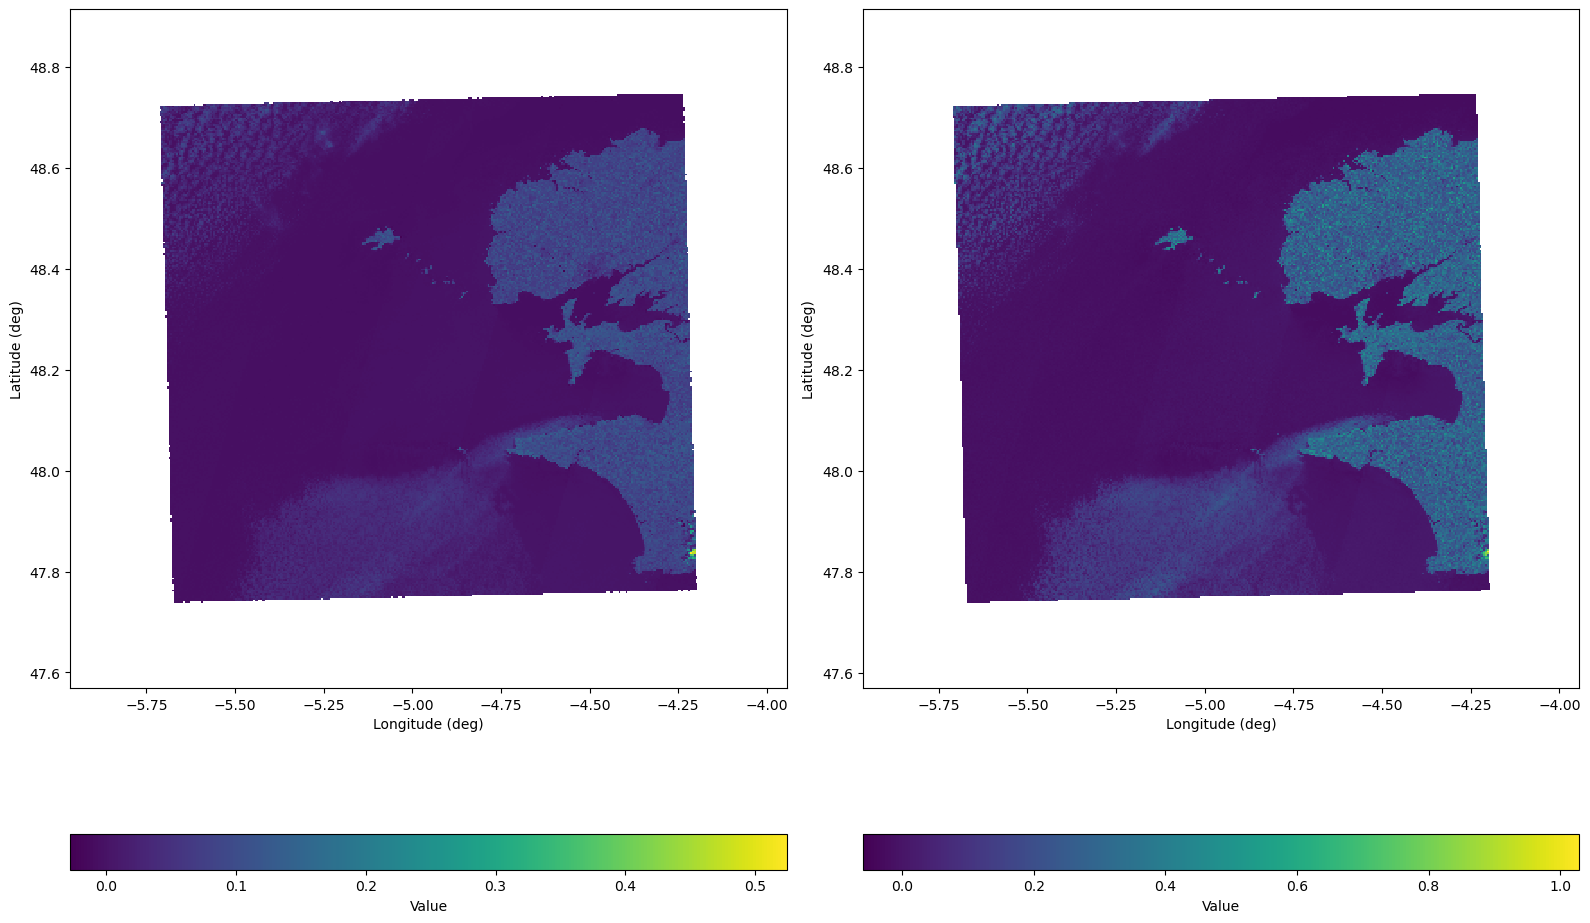

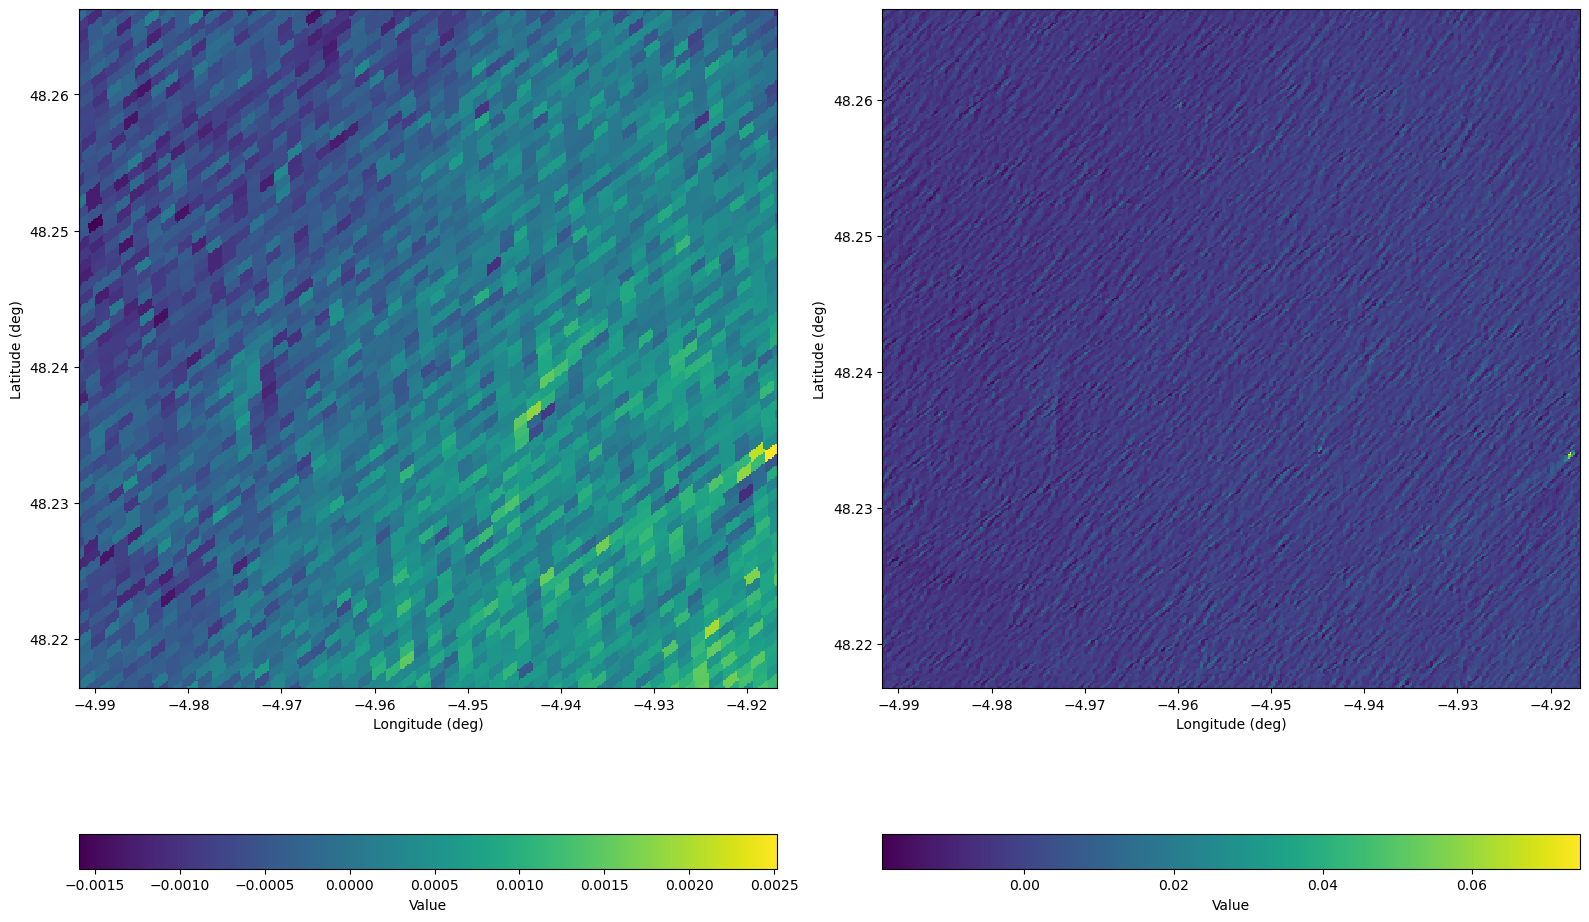

In [8]:
from foscat.Plot import lgnomproject

plt.figure(figsize=(16,10))
lgnomproject(c1,v1-np.median(v1),2**16,hold=False,sub=(1,2,1),cbar=True)
lgnomproject(c2,v2-np.median(v2),2**18,hold=False,sub=(1,2,2),cbar=True)
plt.figure(figsize=(16,10))
lgnomproject(c1,v1-np.median(v1),2**16,hold=False,sub=(1,2,1),cbar=True,fov_deg=0.05)
lgnomproject(c2,v2-np.median(v2),2**18,hold=False,sub=(1,2,2),cbar=True,fov_deg=0.05)


## Downgrade 60m to 20m

The next cell downgrades the HEALPix data from 20m resolution at level 18 to level 16.  
It uses the **Down** function from the **SphericalStencil** module of the **foscat** package.  
This function performs a downgrade by one level, returning the corresponding `cell_ids` values.
    

<Axes: xlabel='Longitude (deg)', ylabel='Latitude (deg)'>

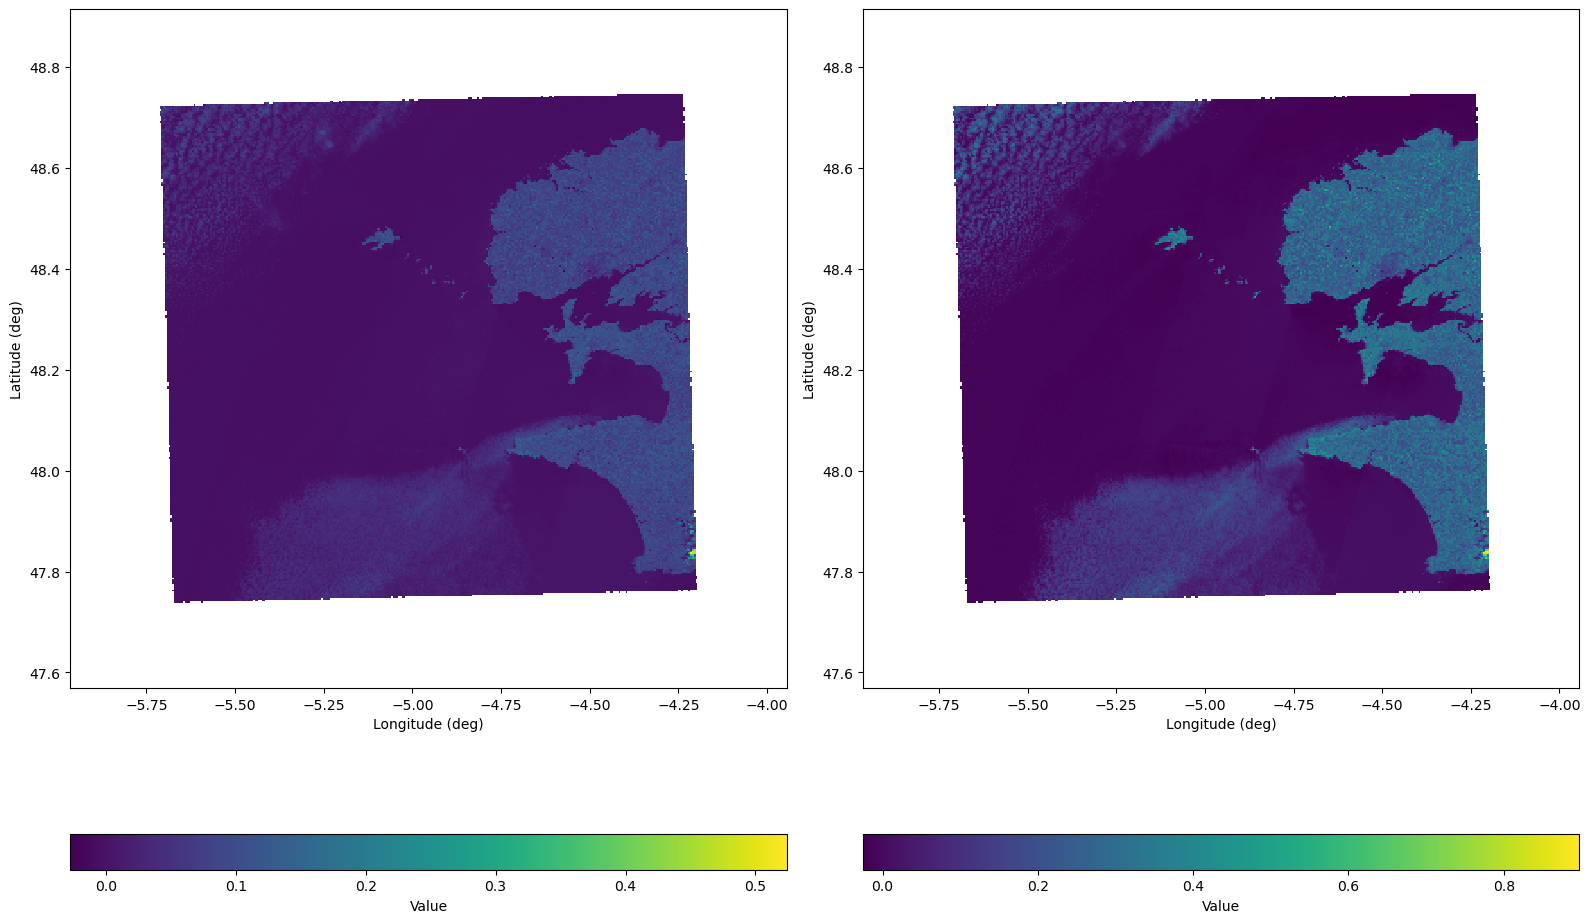

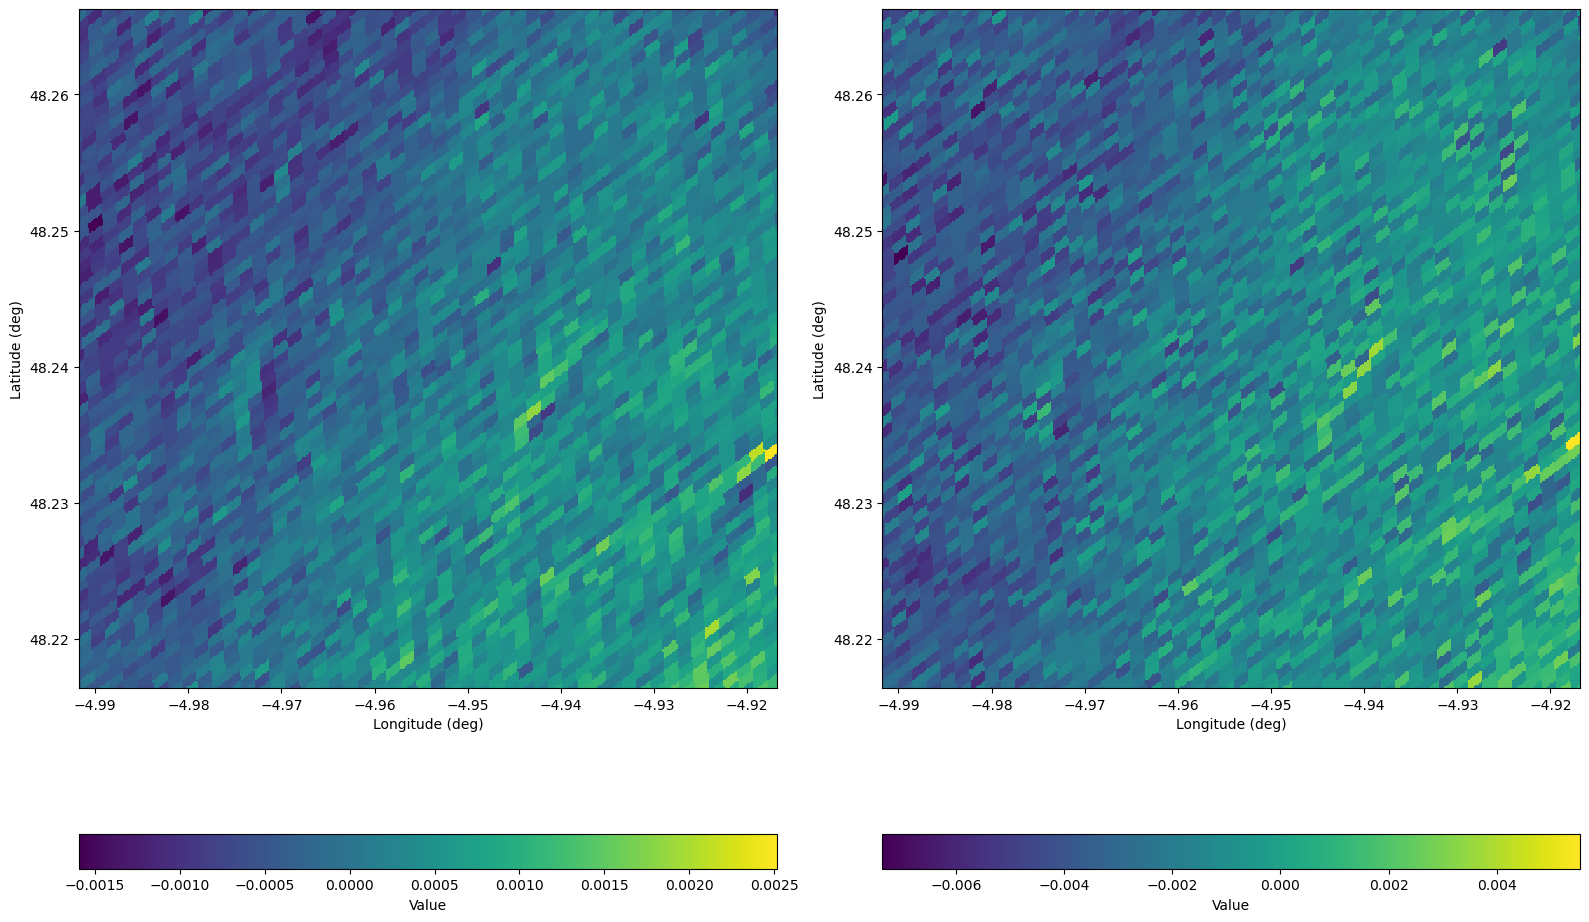

In [9]:
import foscat.SphericalStencil as st
KERNELSZ=5

# reduce the resolution of the nside*2**18 to 2**16
f=st.SphericalStencil(2**16,KERNELSZ,gauge_type='phi',n_gauges=1)

vr_2,cr_2=f.Down(v2,cell_ids=c2,nside=2**18)
vr_2,cr_2=f.Down(vr_2,cell_ids=cr_2,nside=2**17)
vr_2=f.to_numpy(vr_2)
cr_2=f.to_numpy(cr_2)

# keep only common cell_ids
cell_ids = np.intersect1d(c1, cr_2)

# Masques de sélection
mask1 = np.isin(c1, cell_ids)
mask2 = np.isin(cr_2, cell_ids)

# Extraction
v1_common = v1[mask1]
v2_common = vr_2[mask2]

#release memory
del vr_2,cr_2,c1,v1,c2,v2

plt.figure(figsize=(16,10))
lgnomproject(cell_ids,v1_common-np.median(v1_common),2**16,hold=False,sub=(1,2,1),cbar=True)
lgnomproject(cell_ids,v2_common-np.median(v2_common),2**16,hold=False,sub=(1,2,2),cbar=True)
plt.figure(figsize=(16,10))
lgnomproject(cell_ids,v1_common-np.median(v1_common),2**16,hold=False,sub=(1,2,1),cbar=True,fov_deg=0.05)
lgnomproject(cell_ids,v2_common-np.median(v2_common),2**16,hold=False,sub=(1,2,2),cbar=True,fov_deg=0.05)

### Define a convolution kernel

The convolution kernel is defined as the real and imaginary parts of a Morlet wavelet.  
It is used to compute the correlated signal at a given scale.

---

### Why use `x * conj(y)` for correlation?

For two complex signals $x(t)$ and $y(t)$, the cross-correlation is defined as:

$C_{xy}(\tau) = \sum_t x(t)\,\overline{y(t-\tau)}$

where \(\overline{y}\) denotes the complex conjugate of $y$.

- The **complex conjugate** ensures that both **amplitude** and **phase alignment** are taken into account.  
- Without the conjugate, two signals identical in shape but shifted by $\pi/2$ (in quadrature) would yield zero correlation.  
- With the conjugate, the phase of $y$ is inverted, so when multiplied with $x$, the phase terms cancel if the signals are aligned.

In other words:  

$x(t) = A_x e^{i\phi_x}, \quad y(t) = A_y e^{i\phi_y}$

$x(t) \cdot \overline{y(t)} = A_x A_y e^{i(\phi_x - \phi_y)}$

- The magnitude $A_x A_y$ reflects the similarity in **amplitude**.  
- The exponential term $e^{i(\phi_x - \phi_y)}$ encodes the **phase difference**.  
- When phases match $\phi_x \approx \phi_y$, the product is maximized.

Thus, multiplying by the conjugate transforms the correlation into a **measure of similarity** that captures both amplitude and phase alignment.  

Using a Morlet wavelet as the convolution kernel means that the signal is correlated with a localized oscillation (a Gaussian-windowed sinusoid), allowing **time–frequency analysis** at a given scale.

    

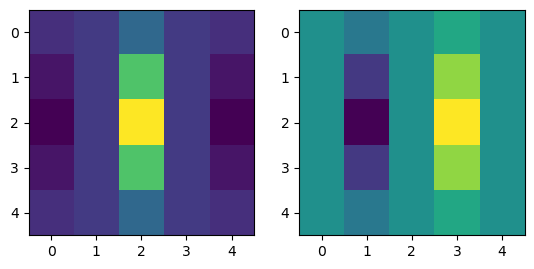

In [10]:
KERNELSZ=5

# Build a 2D meshgrid of size KERNELSZ × KERNELSZ centered on 0
x,y=np.meshgrid(np.arange(KERNELSZ)-KERNELSZ//2,
                np.arange(KERNELSZ)-KERNELSZ//2)

# Initialize a 4D array to store the kernel:
# dimensions are (batch=1, real/imag=2, KERNELSZ, KERNELSZ)
ww=np.zeros([1,2,KERNELSZ,KERNELSZ])

# First component: Gaussian envelope × cosine oscillation
ww[0,0]=np.exp(-0.4*(x**2+y**2))*np.cos(x*np.pi/2)

# Second component: Gaussian envelope × sine oscillation (quadrature)
ww[0,1]=np.exp(-0.4*(x**2+y**2))*np.sin(x*np.pi/2)

# Remove the mean from each component (to enforce zero-mean wavelet)
ww[0,0]-=np.mean(ww[0,0])
ww[0,1]-=np.mean(ww[0,1])

# Normalize the kernel so that the sum of squares of both components equals 1
ww/=np.sqrt(np.sum(ww[0,0]**2+ww[0,1]**2))

# Display the two components of the kernel
plt.subplot(1,2,1)
plt.imshow(ww[0,0])
plt.subplot(1,2,2)
plt.imshow(ww[0,1])

# Do the convolution on **b09** and **b07**

In [11]:
import foscat.SphericalStencil as st

level=16

f=st.SphericalStencil(2**16,KERNELSZ,gauge_type='phi',
                          n_gauges=4,cell_ids=cell_ids)

# Convert the wavelet kernel into a tensor compatible with FOSCAT operations
ww=f.to_tensor(ww.reshape(1,2,KERNELSZ*KERNELSZ))

a=f.to_numpy(f.Convol_torch(f.to_tensor(v1_common[None,None,:]),ww))
b=f.to_numpy(f.Convol_torch(f.to_tensor(v2_common[None,None,:]),ww))#,cell_ids=cell_ids,nside=2**level))

a=a[0,2*np.arange(4)]+1J*a[0,2*np.arange(4)+1]
b=b[0,2*np.arange(4)]+1J*b[0,2*np.arange(4)+1]

a/=a.std()
b/=b.std()

## And plot the results..

<Axes: title={'center': '|x|'}, xlabel='Longitude (deg)', ylabel='Latitude (deg)'>

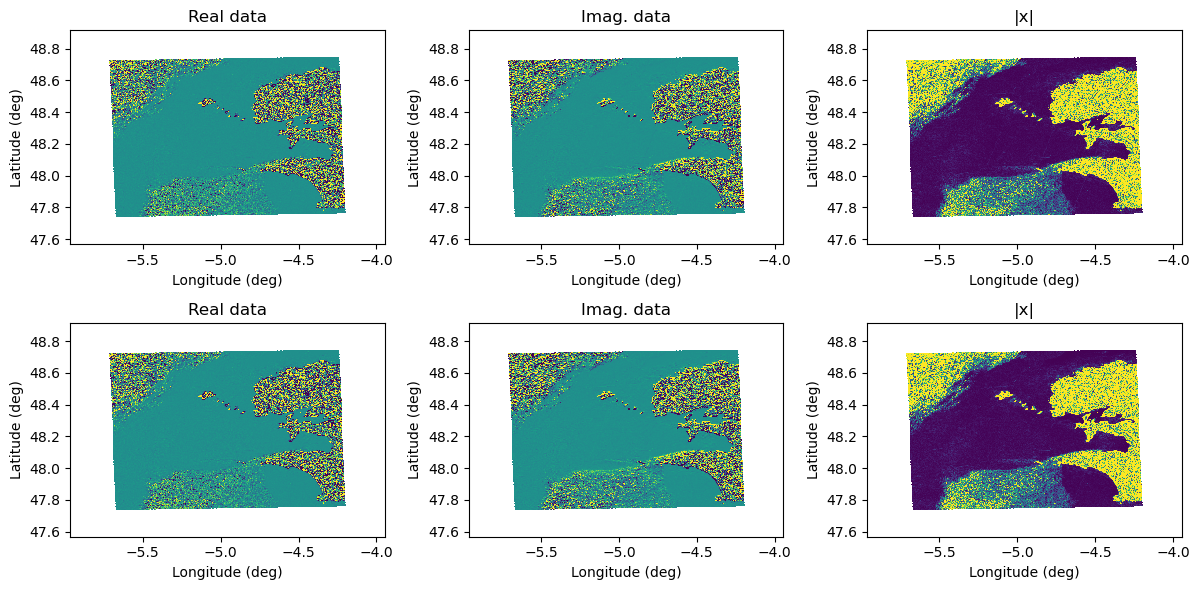

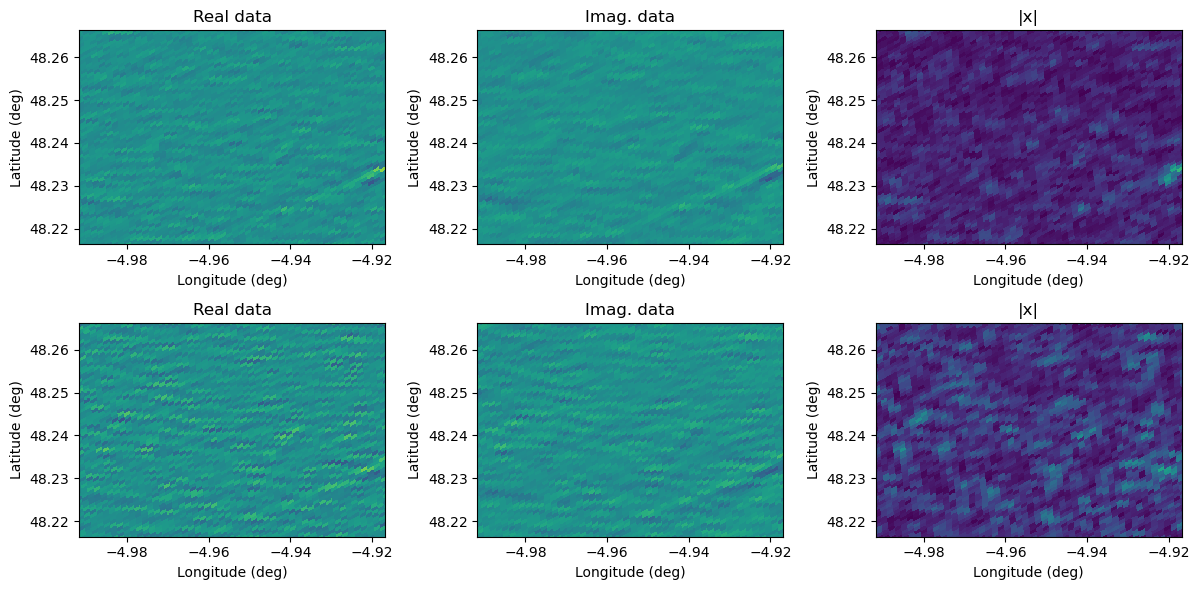

In [12]:
amp=1
plt.figure(figsize=(16,6))
lgnomproject(cell_ids,a[0].real,2**level,hold=False,sub=(2,4,1),vmin=-amp,vmax=amp,title='Real data')
lgnomproject(cell_ids,a[0].imag,2**level,hold=False,sub=(2,4,2),vmin=-amp,vmax=amp,title='Imag. data')
lgnomproject(cell_ids,abs(a[0]),2**level,hold=False,sub=(2,4,3),vmin=0,vmax=amp,title='|x|')
lgnomproject(cell_ids,b[0].real,2**level,hold=False,sub=(2,4,5),vmin=-amp,vmax=amp,title='Real data')
lgnomproject(cell_ids,b[0].imag,2**level,hold=False,sub=(2,4,6),vmin=-amp,vmax=amp,title='Imag. data')
lgnomproject(cell_ids,abs(b[0]),2**level,hold=False,sub=(2,4,7),vmin=0,vmax=amp,title='|x|')
amp=0.2
plt.figure(figsize=(16,6))
lgnomproject(cell_ids,a[0].real,2**level,hold=False,sub=(2,4,1),vmin=-amp,vmax=amp,
             title='Real data',fov_deg=0.05)
lgnomproject(cell_ids,a[0].imag,2**level,hold=False,sub=(2,4,2),vmin=-amp,vmax=amp
             ,title='Imag. data',fov_deg=0.05)
lgnomproject(cell_ids,abs(a[0]),2**level,hold=False,sub=(2,4,3),vmin=0,vmax=amp,title='|x|',fov_deg=0.05)
lgnomproject(cell_ids,b[0].real,2**level,hold=False,sub=(2,4,5),vmin=-amp,vmax=amp,title='Real data',fov_deg=0.05)
lgnomproject(cell_ids,b[0].imag,2**level,hold=False,sub=(2,4,6),vmin=-amp,vmax=amp,title='Imag. data',fov_deg=0.05)
lgnomproject(cell_ids,abs(b[0]),2**level,hold=False,sub=(2,4,7),vmin=0,vmax=amp,title='|x|',fov_deg=0.05)

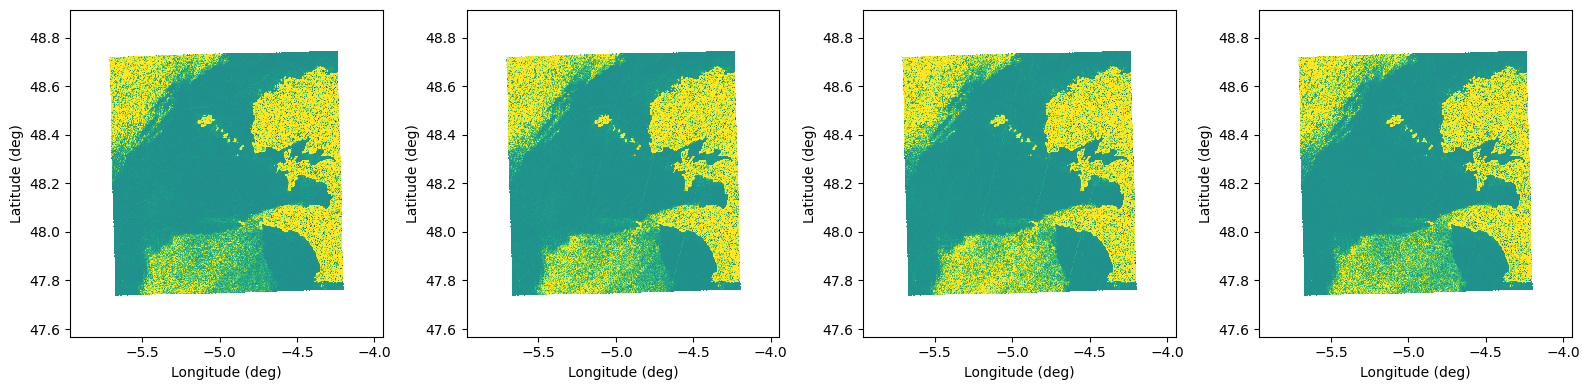

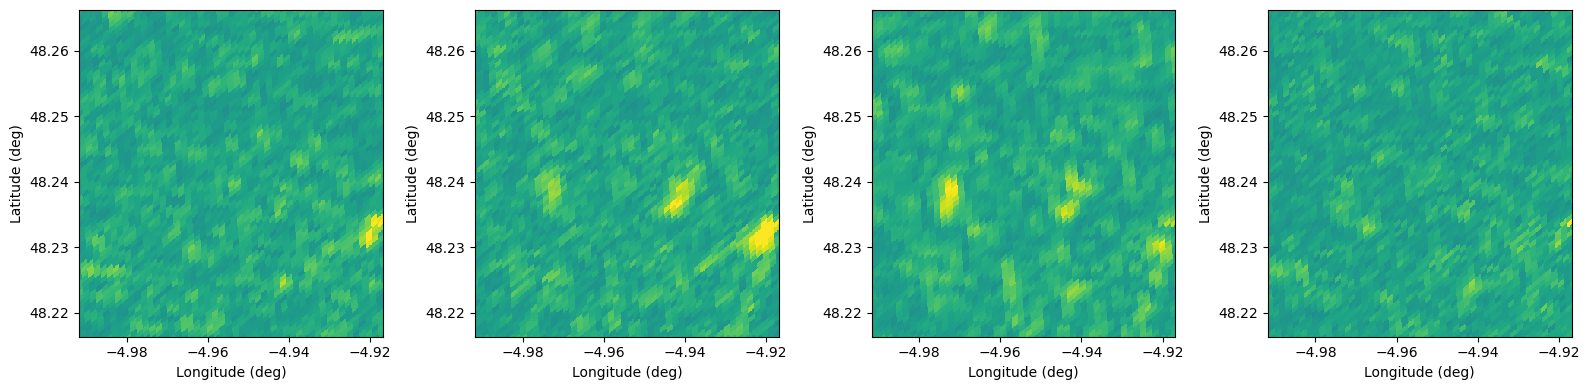

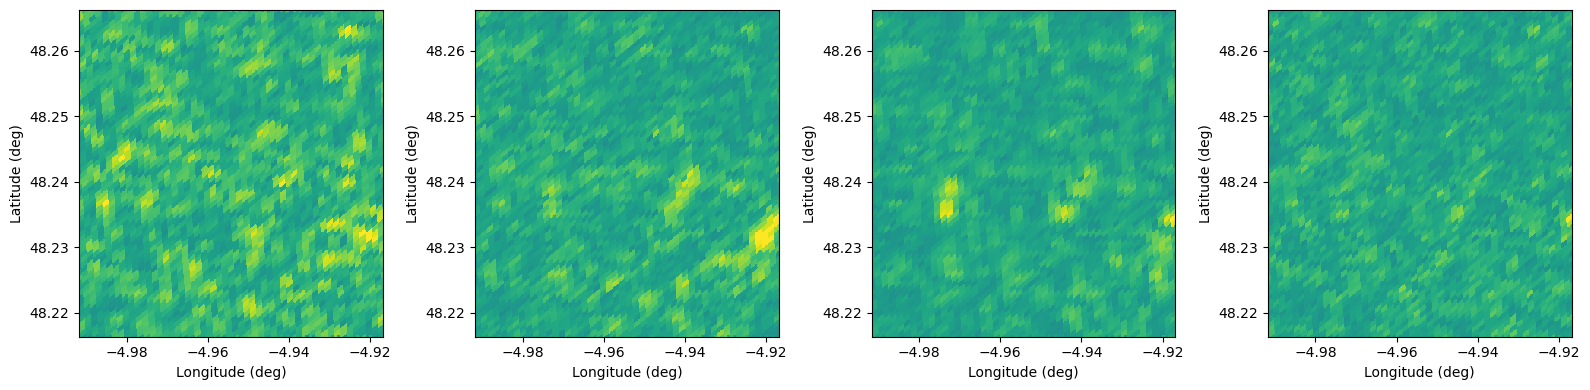

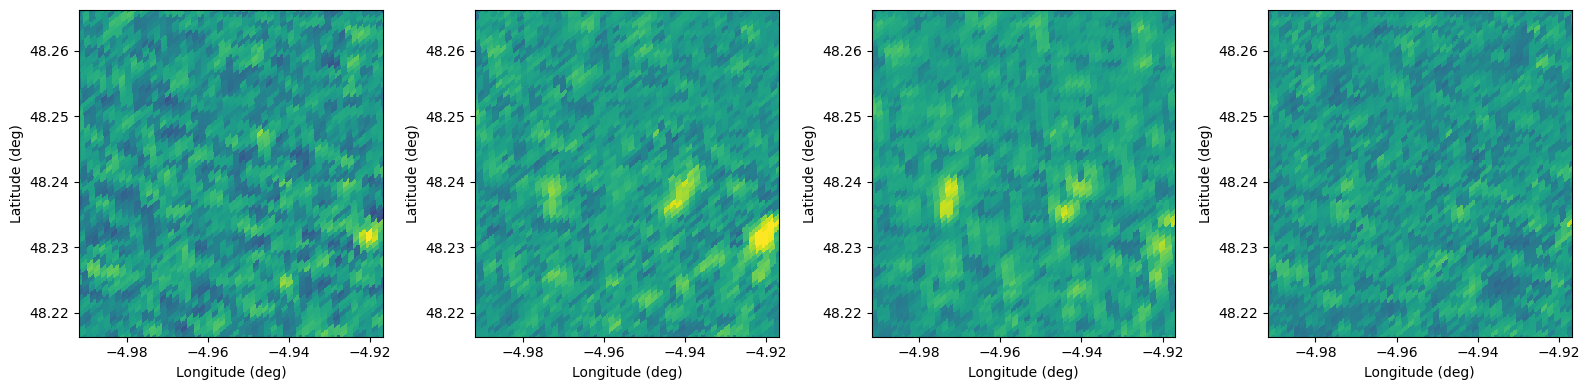

In [13]:
corr=(a*np.conjugate(b)).real
corr=np.sign(corr)*np.sqrt(abs(corr))
amp=1
plt.figure(figsize=(16,4))
for k in range(4):
    lgnomproject(cell_ids,corr[k],2**level,hold=False,sub=(1,4,1+k),vmin=-amp,vmax=amp)
amp=0.1
plt.figure(figsize=(16,4))
for k in range(4):
    lgnomproject(cell_ids,abs(a[k]),2**level,hold=False,sub=(1,4,1+k),vmin=-amp,vmax=amp,fov_deg=0.05)
plt.figure(figsize=(16,4))
for k in range(4):
    lgnomproject(cell_ids,abs(b[k]),2**level,hold=False,sub=(1,4,1+k),vmin=-amp,vmax=amp,fov_deg=0.05)
plt.figure(figsize=(16,4))
for k in range(4):
    lgnomproject(cell_ids,corr[k],2**level,hold=False,sub=(1,4,1+k),vmin=-amp,vmax=amp,fov_deg=0.05)